# Iris Flower Classification

### Task-1: Machine Learning with Scikit-learn

Iris flower has 3 species: **Setosa**, **Versicolor**, and **Virginica** which differ according to their measurements. Hereby multiple ML models are trained to classify them based on sepal and petal dimensions

## 1.Import reqd. libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully')


Libraries imported successfully


## Load and explore dataset

In [4]:
df=pd.read_csv(r"C:\Users\Dell\Desktop\INTERNSHIPS\Oasis_Info_Byte(DS)\Task_1_Iris_Classification\Dataset\Iris.csv")
df=df.drop('Id',axis=1)
print('Shape: ',df.shape)
df.head(10)

Shape:  (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [9]:
print('Class_Distribution:')
print(df['Species'].value_counts())
print()
print('Missing Values: ',df.isnull().sum().sum())

Class_Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing Values:  0


In [10]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3.Exploratory Data Analysis(EDA)

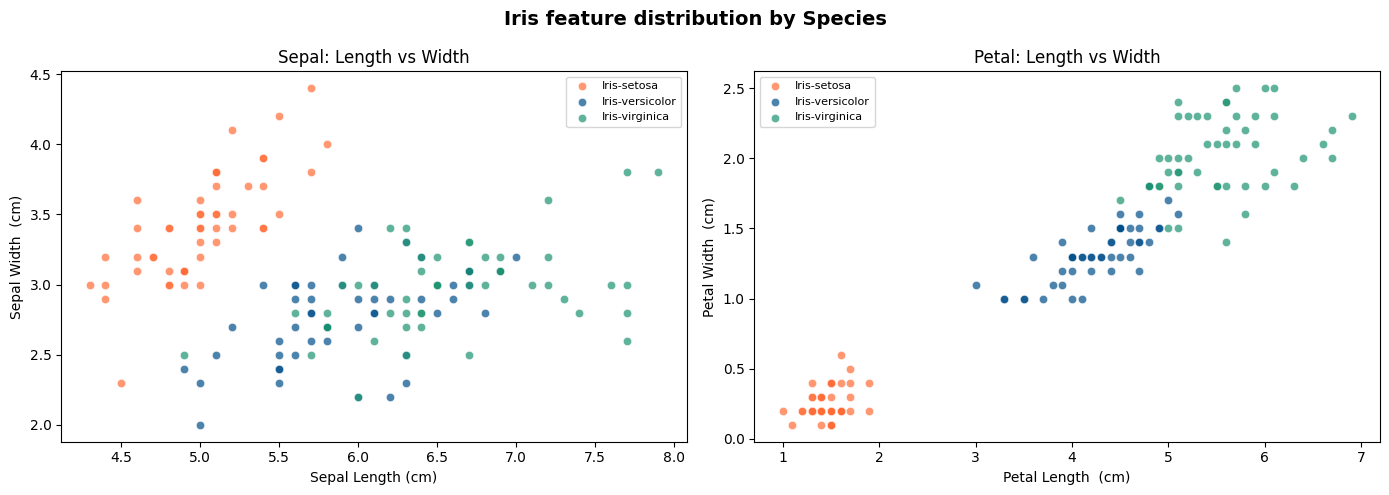

In [20]:
palette = {'Iris-setosa': '#FF6B35', 'Iris-versicolor': '#004E89', 'Iris-virginica': '#1A936F'}

fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Iris feature distribution by Species',fontsize=14, fontweight='bold')

# Sepal scatter
for species,color in palette.items():
    mask= df['Species']== species
    axes[0].scatter(df[mask]['SepalLengthCm'],df[mask]['SepalWidthCm'], label=species, color=color, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width  (cm)')
axes[0].set_title('Sepal: Length vs Width')
axes[0].legend(fontsize=8)

# Petal scatter
for species,color in palette.items():
    mask=df['Species']==species
    axes[1].scatter(df[mask]['PetalLengthCm'],df[mask]['PetalWidthCm'],label=species, color=color, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Petal Length  (cm)')
axes[1].set_ylabel('Petal Width  (cm)')
axes[1].set_title('Petal: Length vs Width')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

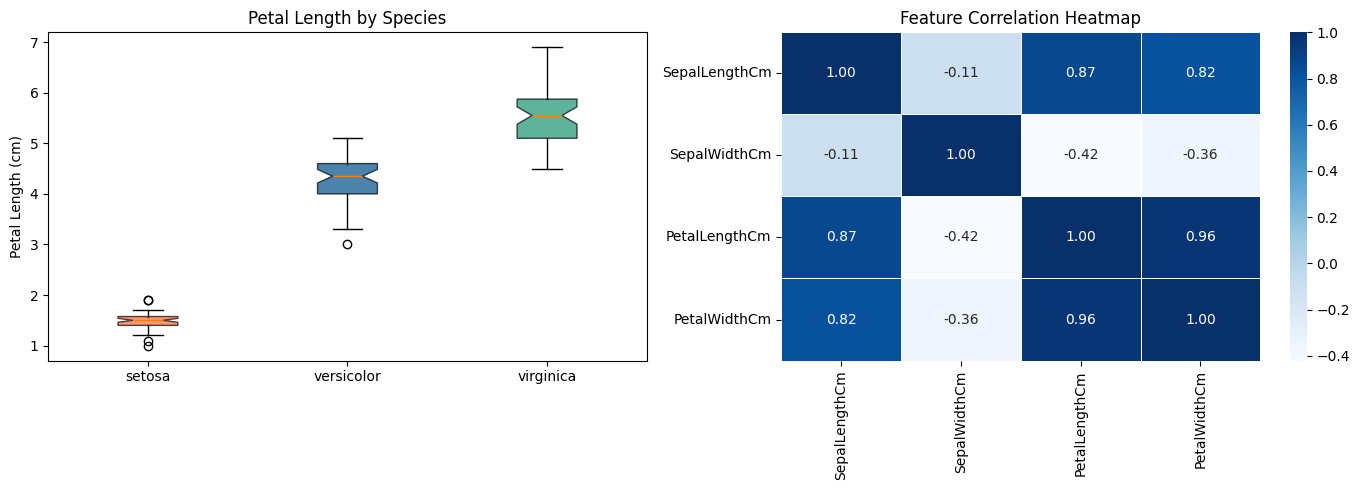

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Box plot petal length
species_list=df['Species'].unique()
data_petal=[df[df['Species']==s]['PetalLengthCm'].values for s in species_list]
bp=axes[0].boxplot(data_petal, patch_artist=True, notch=True)

for patch, color in zip(bp['boxes'], ['#FF6B35', '#004E89', '#1A936F']):
    patch.set_facecolor(color); patch.set_alpha(0.7)

axes[0].set_xticklabels([s.split('-')[1] for s in species_list])
axes[0].set_title('Petal Length by Species'); axes[0].set_ylabel('Petal Length (cm)')

# Correlation heatmap
corr = df.drop('Species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()


## 4. Data_Preprocessing and train_test_split

In [24]:
X= df.drop('Species',axis=1)
y= df['Species']

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_train)}')
print(f'Features {list(X.columns)}')

Training samples: 120
Testing samples: 120
Features ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


## 5. Train and compare multiple models

In [26]:
models={
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results={}
print(f"{'Model':<22} {'Test Acc':>9} {'CV Mean':>9} {'CV Std':>8}")
print("-" * 52)

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred= model.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    cv= cross_val_score(model, X, y, cv=5)
    results[name]= {'accuracy': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std(), 'model': model , 'y_pred': y_pred}
    print(f"{name:<22} {acc:>9.4f} {cv.mean():>9.4f} {cv.std():>8.4f}")

Model                   Test Acc   CV Mean   CV Std
----------------------------------------------------
Logistic Regression       0.9667    0.9733   0.0249
Decision Tree             0.9333    0.9533   0.0340
Random Forest             0.9000    0.9667   0.0211
SVM                       0.9667    0.9667   0.0211
KNN                       1.0000    0.9733   0.0249


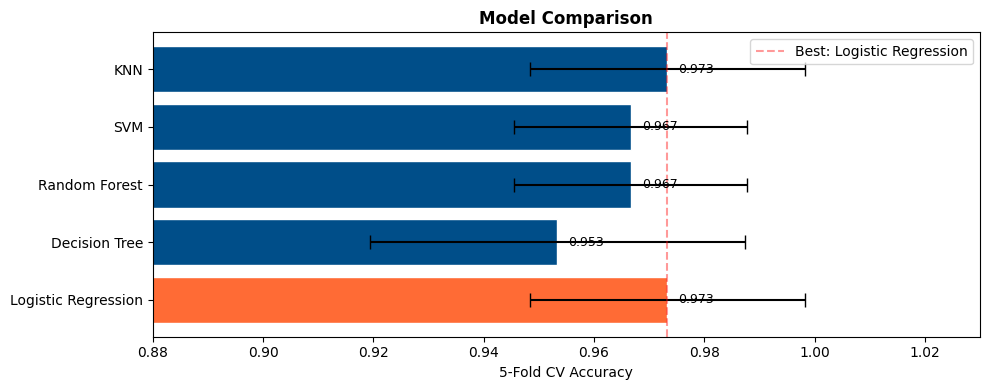


🏆 Best Model: Logistic Regression


In [27]:
# Model comparison bar chart
names = list(results.keys())
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]
best_name = max(results, key=lambda k: results[k]['cv_mean'])
colors = ['#FF6B35' if n == best_name else '#004E89' for n in names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(names, cv_means, xerr=cv_stds, color=colors, edgecolor='white', capsize=5)
ax.set_xlabel('5-Fold CV Accuracy'); ax.set_title('Model Comparison', fontweight='bold')
ax.set_xlim(0.88, 1.03)
for bar, val in zip(bars, cv_means):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.axvline(x=max(cv_means), color='red', linestyle='--', alpha=0.4, label=f'Best: {best_name}')
ax.legend()
plt.tight_layout(); plt.show()
print(f"\n🏆 Best Model: {best_name}")


## 6. Best Model Evaluation

In [30]:
best_pred = results[best_name]['y_pred']
print(f"Best Model: {best_name}")
print(f"Test Accuracy: {results[best_name]['accuracy']:.4f}\n")
print(classification_report(y_test, best_pred))

Best Model: Logistic Regression
Test Accuracy: 0.9667

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



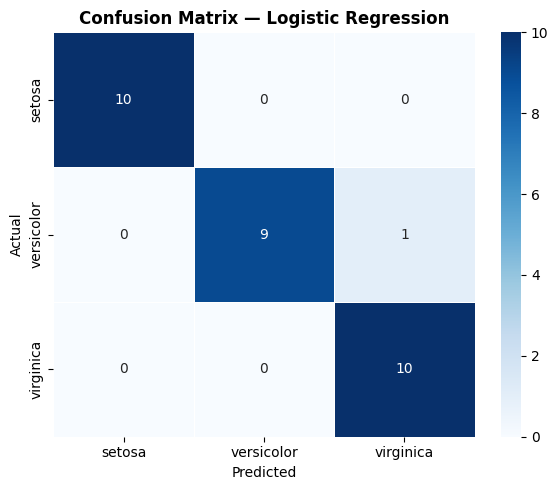

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
labels = sorted(y.unique())
short_labels = [l.split('-')[1] for l in labels]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

##  7. Feature Importance (Random Forest)

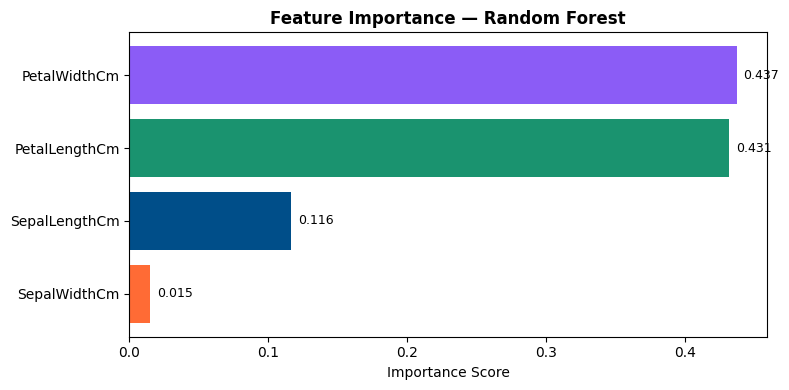

In [32]:
rf = results['Random Forest']['model']
importances = rf.feature_importances_
feat_names = X.columns
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(feat_names[idx], importances[idx],
               color=['#FF6B35','#004E89','#1A936F','#8B5CF6'])
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importances[idx]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

##  8. Conclusions

| Model | CV Accuracy |
|---|---|
| **Logistic Regression** | **97.33%** |
| KNN | 97.33% |
| SVM | 96.67% |
| Random Forest | 96.67% |
| Decision Tree | 95.33% |

**Key Takeaways:**
- 🥇 **Logistic Regression** achieves the best cross-validated accuracy (97.33%) with low variance
- 🌸 **Iris Setosa** is perfectly separable — 100% precision & recall across all models
- 🔑 **Petal features** (especially Petal Length) are the most discriminating features
- ⚠️ **Versicolor vs Virginica** is the hardest boundary due to overlapping measurements